# Section 4.2.6 — DTOF descriptor controls
Generate two thesis-facing figures after all required experiments are complete. Figure 1 compares the retrained tHb zero-vector and shuffled-subject controls directly with the DTOF descriptor model. Figure 2 shows random single-acquisition sensitivity for tHb and StO₂ using 30 draws per held-out subject.

The notebook does not rerun training or inference. It reads completed result CSV files, verifies all 154 LOSO subjects, computes paired subject-level statistics, and writes figures plus rebuildable tables.

## 1. Setup and paths
For Figure 1, $\Delta RMSE = RMSE_{control} - RMSE_{DTOF\ descriptor}$. For random acquisition, $\Delta RMSE = RMSE_{random\ acquisition} - RMSE_{DTOF\ descriptor}$. Positive values therefore indicate worse performance than the correctly paired representative DTOF descriptor. StO₂ errors are converted from fractions to percentage points.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy.stats import rankdata, wilcoxon

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)

EXPECTED_SUBJECTS = 154
RNG_SEED = 20260914

ACTUAL_PATHS = {
    'hc': Path('artifacts/stage2/residual/finetune/dtof/hc/loso_results.csv'),
    'sto2': Path('artifacts/stage2/residual/finetune/dtof/sto2/loso_results.csv'),
}
TRAINING_CONTROL_PATHS = {
    'Zero vector': Path('artifacts/stage2/residual/finetune/dtof_zero/hc/loso_results.csv'),
    'Shuffled subject': Path('artifacts/stage2/residual/finetune/dtof_shuffle/hc/loso_results.csv'),
}
RANDOM_PATHS = {
    'hc': Path('artifacts/stage2/descriptor_controls/random_acquisition/hc/per_subject_repeat_metrics.csv'),
    'sto2': Path('artifacts/stage2/descriptor_controls/random_acquisition/sto2/per_subject_repeat_metrics.csv'),
}
FIGURE_DIR = Path('results/figures/stage2/descriptor_controls')
TABLE_DIR = Path('results/tables/stage2/descriptor_controls')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

THB_CONTROL_FIGURE = FIGURE_DIR / 'fig_section_426_thb_descriptor_controls.png'
RANDOM_FIGURE = FIGURE_DIR / 'fig_section_426_random_acquisition_sensitivity.png'
THB_CONTROL_DETAIL = TABLE_DIR / 'thb_training_control_paired_results.csv'
RANDOM_DETAIL = TABLE_DIR / 'random_acquisition_subject_summary.csv'
SUMMARY_TABLE = TABLE_DIR / 'section_426_control_summary.csv'

FIGURE_DIR, TABLE_DIR

(PosixPath('results/figures/stage2/descriptor_controls'),
 PosixPath('results/tables/stage2/descriptor_controls'))

## 2. Validation and paired-statistics helpers
Every analysis uses the held-out subject as the statistical unit. Random-acquisition repeats are first reduced within subject and are never treated as independent observations.

In [2]:
def require_columns(frame, columns, path):
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise ValueError(f'{path} is missing columns: {missing}')


def require_complete_subjects(frame, path):
    ids = pd.to_numeric(frame['test_id'], errors='raise').astype(int)
    observed = set(ids.tolist())
    expected = set(range(EXPECTED_SUBJECTS))
    if observed != expected:
        missing = sorted(expected - observed)
        extra = sorted(observed - expected)
        raise RuntimeError(
            f'{path} is incomplete: {len(observed)}/{EXPECTED_SUBJECTS} subjects; '
            f'missing={missing}, extra={extra}'
        )


def load_loso_rmse(path, target):
    if not path.is_file():
        raise FileNotFoundError(f'Missing LOSO result: {path}')
    frame = pd.read_csv(path)
    metric = 'test_GM_hc_RMSE' if target == 'hc' else 'test_GM_StO2_RMSE'
    require_columns(frame, ['fold', 'test_id', metric], path)
    require_complete_subjects(frame, path)
    if frame['test_id'].duplicated().any():
        duplicates = sorted(frame.loc[frame['test_id'].duplicated(False), 'test_id'].unique())
        raise ValueError(f'{path} has duplicate test IDs: {duplicates}')
    output = frame[['fold', 'test_id', metric]].copy()
    output[metric] = pd.to_numeric(output[metric], errors='raise')
    if not np.isfinite(output[metric]).all():
        raise ValueError(f'{path} contains non-finite RMSE values')
    return output.rename(columns={metric: 'RMSE'})


def matched_rank_biserial(delta):
    values = np.asarray(delta, dtype=float)
    values = values[np.isfinite(values) & (values != 0)]
    if values.size == 0:
        return 0.0
    ranks = rankdata(np.abs(values), method='average')
    return float((ranks[values > 0].sum() - ranks[values < 0].sum()) / ranks.sum())


def paired_summary(delta, reference, comparator, target, comparison, analysis, reference_label):
    delta = np.asarray(delta, dtype=float)
    reference = np.asarray(reference, dtype=float)
    comparator = np.asarray(comparator, dtype=float)
    if not (len(delta) == len(reference) == len(comparator) == EXPECTED_SUBJECTS):
        raise ValueError('Paired summary requires 154 aligned subjects')
    p_value = 1.0 if np.all(delta == 0) else float(
        wilcoxon(delta, zero_method='wilcox', alternative='two-sided', method='auto').pvalue
    )
    return {
        'target': target,
        'comparison': comparison,
        'analysis': analysis,
        'reference': reference_label,
        'n_subjects': len(delta),
        'reference_RMSE_median': float(np.median(reference)),
        'reference_RMSE_q1': float(np.quantile(reference, 0.25)),
        'reference_RMSE_q3': float(np.quantile(reference, 0.75)),
        'comparator_RMSE_median': float(np.median(comparator)),
        'comparator_RMSE_q1': float(np.quantile(comparator, 0.25)),
        'comparator_RMSE_q3': float(np.quantile(comparator, 0.75)),
        'delta_RMSE_median': float(np.median(delta)),
        'delta_RMSE_q1': float(np.quantile(delta, 0.25)),
        'delta_RMSE_q3': float(np.quantile(delta, 0.75)),
        'comparator_worse_fraction': float(np.mean(delta > 0)),
        'paired_wilcoxon_p': p_value,
        'rank_biserial_actual_better': matched_rank_biserial(delta),
    }


def holm_adjust(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    adjusted_sorted = np.maximum.accumulate((len(values) - np.arange(len(values))) * values[order])
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted


def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#D9DEE7', linewidth=0.8, alpha=0.75)
    ax.set_axisbelow(True)


def format_p(p_value):
    return '< 0.001' if float(p_value) < 0.001 else f'= {float(p_value):.3f}'


def format_control_annotation(row, unit, adjusted=True):
    p_column = 'holm_adjusted_p' if adjusted else 'paired_wilcoxon_p'
    p_label = r'$p_{\mathrm{Holm}}$' if adjusted else r'$p$'
    return (
        f"Median [Q1, Q3]: {row['delta_RMSE_median']:.2f} "
        f"[{row['delta_RMSE_q1']:.2f}, {row['delta_RMSE_q3']:.2f}] {unit}\n"
        f"Worsened: {100 * row['comparator_worse_fraction']:.1f}%\n"
        f"{p_label} {format_p(row[p_column])}"
    )

## 3. Figure 1 — retrained tHb controls
Both controls use the same gated-residual fusion, DRS-only-checkpoint initialization, and training budget as the DTOF descriptor model. Direct paired differences isolate whether descriptor variation and correct subject pairing add information beyond the shared fine-tuning procedure.

In [3]:
actual_hc = load_loso_rmse(ACTUAL_PATHS['hc'], 'hc').rename(columns={'RMSE': 'reference_RMSE'})
training_detail_rows = []
summary_rows = []
for label, path in TRAINING_CONTROL_PATHS.items():
    control = load_loso_rmse(path, 'hc').rename(columns={'RMSE': 'method_RMSE'})
    paired = actual_hc.merge(
        control[['fold', 'test_id', 'method_RMSE']],
        on=['fold', 'test_id'], how='inner', validate='one_to_one',
    )
    if len(paired) != EXPECTED_SUBJECTS:
        raise RuntimeError(f'{label} did not align to all 154 DTOF descriptor subjects')
    paired['comparison'] = label
    paired['delta_RMSE'] = paired['method_RMSE'] - paired['reference_RMSE']
    training_detail_rows.append(paired)
    summary_rows.append(paired_summary(
        paired['delta_RMSE'], paired['reference_RMSE'], paired['method_RMSE'],
        target='tHb', comparison=label, analysis='retrained control',
        reference_label='DTOF descriptor',
    ))

training_detail = pd.concat(training_detail_rows, ignore_index=True)
training_detail.to_csv(THB_CONTROL_DETAIL, index=False)
training_summary = pd.DataFrame(summary_rows)
training_summary['holm_adjusted_p'] = holm_adjust(training_summary['paired_wilcoxon_p'])
display(training_summary)
display(training_detail.groupby('comparison')['delta_RMSE'].describe(percentiles=[0.25, 0.5, 0.75]))

,target,comparison,analysis,reference,n_subjects,reference_RMSE_median,reference_RMSE_q1,reference_RMSE_q3,comparator_RMSE_median,comparator_RMSE_q1,comparator_RMSE_q3,delta_RMSE_median,delta_RMSE_q1,delta_RMSE_q3,comparator_worse_fraction,paired_wilcoxon_p,rank_biserial_actual_better,holm_adjusted_p
0,tHb,Zero vector,retrained control,DTOF descriptor,154,12.49262,9.851041,17.161531,12.855494,10.277107,17.252862,0.403138,-0.980363,1.545959,0.616883,0.077553,0.163972,0.098344
1,tHb,Shuffled subject,retrained control,DTOF descriptor,154,12.49262,9.851041,17.161531,12.676540,10.233500,17.107550,0.361562,-1.108620,1.739021,0.610390,0.049172,0.182740,0.098344


,count,mean,std,min,25%,50%,75%,max
comparison,,,,,,,,
Shuffled subject,154.0,0.192750,3.043432,-9.907083,-1.108620,0.361562,1.739021,7.633959
Zero vector,154.0,0.135497,2.756483,-10.228848,-0.980363,0.403138,1.545959,6.834129


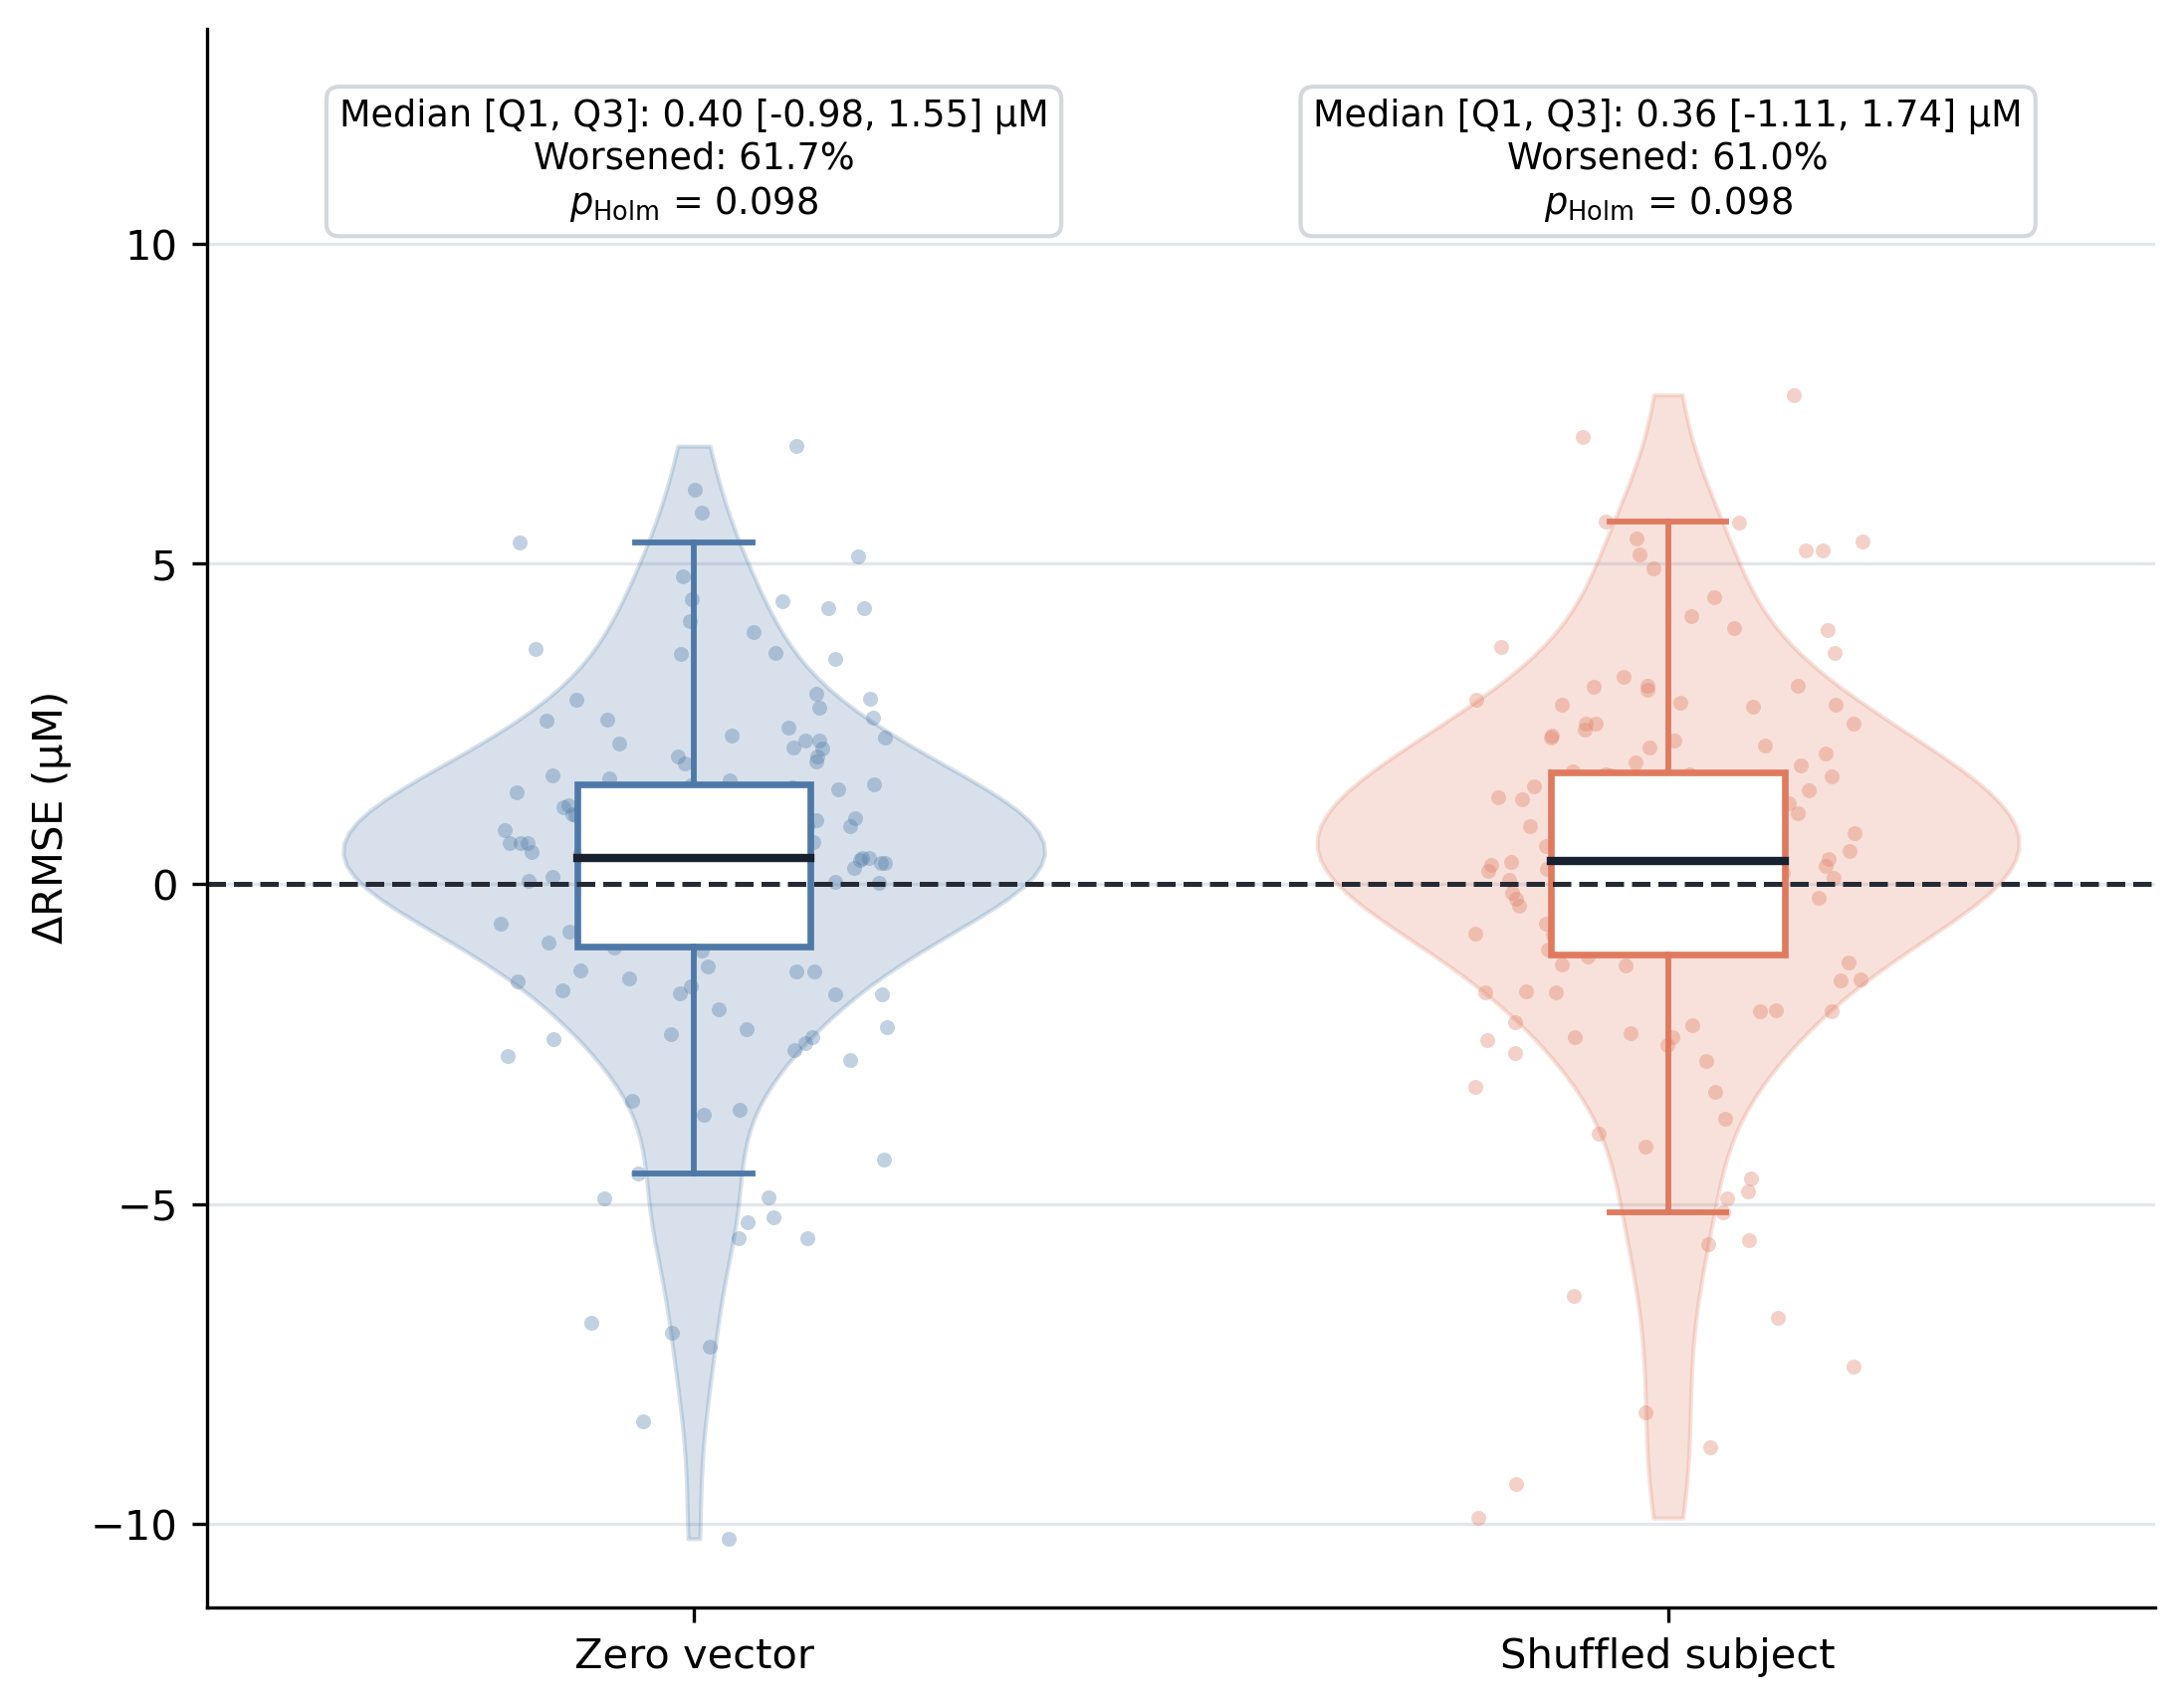

In [4]:
labels = list(TRAINING_CONTROL_PATHS)
groups = [
    training_detail.loc[training_detail['comparison'] == label, 'delta_RMSE'].to_numpy()
    for label in labels
]
colors = ['#4E79A7', '#E07A5F']
rng = np.random.default_rng(RNG_SEED)

fig, ax = plt.subplots(figsize=(7.2, 5.6), constrained_layout=True)
positions = np.arange(1, len(groups) + 1)
parts = ax.violinplot(groups, positions=positions, widths=0.72,
                      showmeans=False, showmedians=False, showextrema=False)
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.22)
for x, values, color in zip(positions, groups, colors):
    jitter = rng.uniform(-0.20, 0.20, len(values))
    ax.scatter(x + jitter, values, s=13, color=color, alpha=0.34,
               linewidths=0, rasterized=True)
    ax.boxplot(values, positions=[x], widths=0.24, patch_artist=True,
               showfliers=False,
               medianprops={'color': '#18212F', 'linewidth': 2.0},
               boxprops={'facecolor': 'white', 'edgecolor': color, 'linewidth': 1.6},
               whiskerprops={'color': color, 'linewidth': 1.4},
               capprops={'color': color, 'linewidth': 1.4})
ax.axhline(0, color='#252A34', linewidth=1.2, linestyle='--')
ax.set_xticks(positions, labels)
ax.set_ylabel(r'$\Delta$RMSE (µM)')
lower = min(float(np.min(values)) for values in groups)
upper = max(float(np.max(values)) for values in groups)
span = max(upper - lower, 1.0)
ax.set_ylim(lower - 0.06 * span, upper + 0.32 * span)
for x, label in zip(positions, labels):
    row = training_summary.loc[training_summary['comparison'] == label].iloc[0]
    ax.text(
        x, upper + 0.26 * span, format_control_annotation(row, 'µM', adjusted=True),
        ha='center', va='top', fontsize=8.8, linespacing=1.25,
        bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB',
              'boxstyle': 'round,pad=0.35', 'alpha': 0.92},
    )
style_axis(ax)
fig.savefig(THB_CONTROL_FIGURE, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(Image(filename=str(THB_CONTROL_FIGURE), width=850))

## 4. Figure 2 — random single-acquisition sensitivity
For each target, subjects are sorted by their median $\Delta RMSE$ across 30 deterministic acquisition draws. The line is the subject median and the shaded region is the within-subject IQR. Sorting is target-specific and is used only for visualization.

In [5]:
random_subject_rows = []
for target, path in RANDOM_PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(
            f'Missing random-acquisition result: {path}. Complete the 30-repeat control first.'
        )
    raw = pd.read_csv(path)
    required = ['fold', 'test_id', 'repeat', 'actual_RMSE', 'control_RMSE', 'delta_RMSE']
    require_columns(raw, required, path)
    require_complete_subjects(raw, path)
    counts = raw.groupby('test_id')['repeat'].nunique()
    if not (counts == 30).all():
        bad = counts[counts != 30].to_dict()
        raise RuntimeError(f'{path} must contain 30 unique repeats per subject; found {bad}')
    if raw.duplicated(['test_id', 'repeat']).any():
        raise ValueError(f'{path} contains duplicate subject-repeat rows')
    numeric = raw[['actual_RMSE', 'control_RMSE', 'delta_RMSE']].apply(pd.to_numeric, errors='raise')
    if not np.isfinite(numeric.to_numpy()).all():
        raise ValueError(f'{path} contains non-finite metrics')

    # Confirm that frozen-checkpoint Actual DTOF inference matches the primary LOSO result.
    primary = load_loso_rmse(ACTUAL_PATHS[target], target).rename(columns={'RMSE': 'primary_actual_RMSE'})
    reported_actual = raw.groupby(['fold', 'test_id'], as_index=False)['actual_RMSE'].agg(
        lambda values: values.iloc[0] if np.allclose(values, values.iloc[0]) else np.nan
    )
    check = primary.merge(reported_actual, on=['fold', 'test_id'], validate='one_to_one')
    if len(check) != EXPECTED_SUBJECTS or not np.allclose(
        check['primary_actual_RMSE'], check['actual_RMSE'], rtol=1e-5, atol=1e-6
    ):
        raise RuntimeError(f'{path} Actual DTOF values do not match the primary LOSO run')

    scale = 1.0 if target == 'hc' else 100.0
    grouped = raw.groupby(['fold', 'test_id'], as_index=False).agg(
        actual_RMSE=('actual_RMSE', 'first'),
        random_RMSE_median=('control_RMSE', 'median'),
        delta_RMSE_median=('delta_RMSE', 'median'),
        delta_RMSE_q1=('delta_RMSE', lambda x: x.quantile(0.25)),
        delta_RMSE_q3=('delta_RMSE', lambda x: x.quantile(0.75)),
    )
    for column in ['actual_RMSE', 'random_RMSE_median', 'delta_RMSE_median',
                   'delta_RMSE_q1', 'delta_RMSE_q3']:
        grouped[column] *= scale
    grouped['target'] = 'tHb' if target == 'hc' else 'StO₂'
    random_subject_rows.append(grouped)
    random_summary = paired_summary(
        grouped['delta_RMSE_median'], grouped['actual_RMSE'],
        grouped['random_RMSE_median'], target=grouped['target'].iloc[0],
        comparison='Random acquisition', analysis='fixed checkpoint; 30 draws',
        reference_label='DTOF descriptor',
    )
    random_summary['within_subject_IQR_median'] = float(np.median(
        grouped['delta_RMSE_q3'] - grouped['delta_RMSE_q1']
    ))
    summary_rows.append(random_summary)

random_subjects = pd.concat(random_subject_rows, ignore_index=True)
random_subjects.to_csv(RANDOM_DETAIL, index=False)
summary = pd.DataFrame(summary_rows)
summary['holm_adjusted_p'] = np.nan
for _, indices in summary.groupby(['target', 'analysis']).groups.items():
    summary.loc[indices, 'holm_adjusted_p'] = holm_adjust(
        summary.loc[indices, 'paired_wilcoxon_p'].to_numpy()
    )
summary.to_csv(SUMMARY_TABLE, index=False)
display(summary)

,target,comparison,analysis,reference,n_subjects,reference_RMSE_median,reference_RMSE_q1,reference_RMSE_q3,comparator_RMSE_median,comparator_RMSE_q1,comparator_RMSE_q3,delta_RMSE_median,delta_RMSE_q1,delta_RMSE_q3,comparator_worse_fraction,paired_wilcoxon_p,rank_biserial_actual_better,within_subject_IQR_median,holm_adjusted_p
0,tHb,Zero vector,retrained control,DTOF descriptor,154,12.492620,9.851041,17.161531,12.855494,10.277107,17.252862,0.403138,-0.980363,1.545959,0.616883,0.077553,0.163972,NaN,0.098344
1,tHb,Shuffled subject,retrained control,DTOF descriptor,154,12.492620,9.851041,17.161531,12.676540,10.233500,17.107550,0.361562,-1.108620,1.739021,0.610390,0.049172,0.182740,NaN,0.098344
2,tHb,Random acquisition,fixed checkpoint; 30 draws,DTOF descriptor,154,12.492620,9.851041,17.161531,12.523865,9.887057,17.314376,0.030805,-0.101150,0.208996,0.616883,0.054153,0.178886,0.967678,0.054153
3,StO₂,Random acquisition,fixed checkpoint; 30 draws,DTOF descriptor,154,4.597495,3.388846,6.644126,4.681114,3.388024,6.718872,0.006245,-0.046735,0.055568,0.545455,0.405140,0.077336,0.262761,0.405140


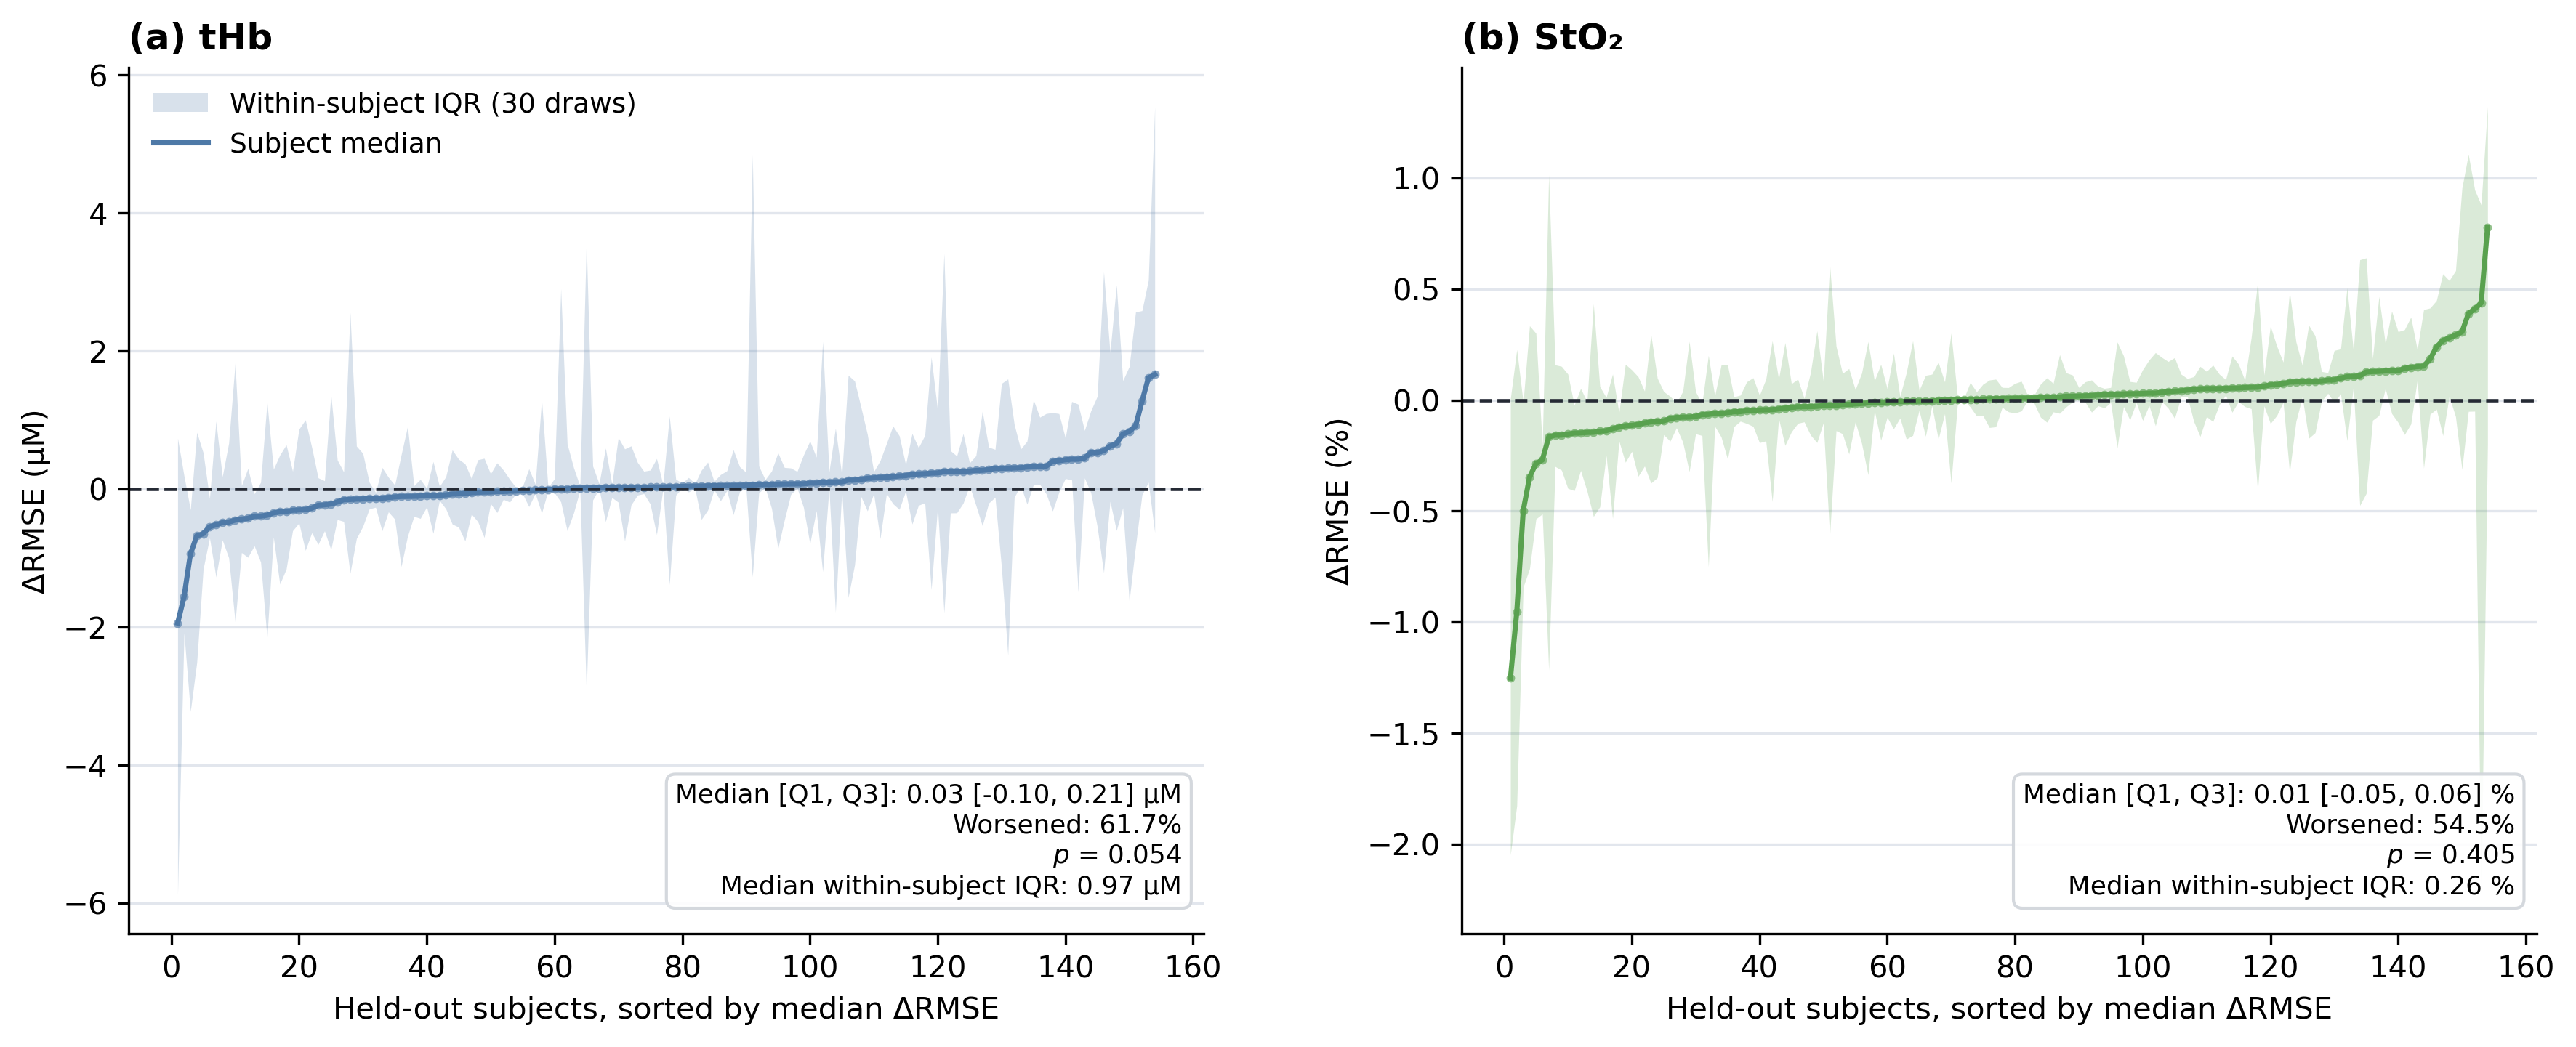

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.3))
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.15, top=0.90, wspace=0.24)
specifications = [
    ('tHb', '(a) tHb', 'µM', '#4E79A7'),
    ('StO₂', '(b) StO₂', '%', '#59A14F'),
]
for ax, (target, panel_label, unit, color) in zip(axes, specifications):
    current = random_subjects.loc[random_subjects['target'] == target].copy()
    current = current.sort_values('delta_RMSE_median').reset_index(drop=True)
    x = np.arange(1, len(current) + 1)
    ax.fill_between(
        x, current['delta_RMSE_q1'].to_numpy(), current['delta_RMSE_q3'].to_numpy(),
        color=color, alpha=0.22, linewidth=0, label='Within-subject IQR (30 draws)',
    )
    ax.plot(x, current['delta_RMSE_median'], color=color, linewidth=1.7,
            label='Subject median')
    ax.scatter(x, current['delta_RMSE_median'], s=8, color=color, alpha=0.65,
               linewidths=0, rasterized=True)
    ax.axhline(0, color='#252A34', linewidth=1.1, linestyle='--')
    ax.set_title(panel_label, loc='left', fontsize=12, fontweight='bold')
    ax.set_xlabel('Held-out subjects, sorted by median ΔRMSE')
    ax.set_ylabel(f'ΔRMSE ({unit})')
    row = summary.loc[
        (summary['target'] == target) & (summary['comparison'] == 'Random acquisition')
    ].iloc[0]
    annotation = format_control_annotation(row, unit, adjusted=False)
    annotation += f"\nMedian within-subject IQR: {row['within_subject_IQR_median']:.2f} {unit}"
    ax.text(
        0.98, 0.04, annotation, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.6, linespacing=1.25,
        bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB',
              'boxstyle': 'round,pad=0.35', 'alpha': 0.92},
    )
    style_axis(ax)
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
fig.savefig(RANDOM_FIGURE, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(Image(filename=str(RANDOM_FIGURE), width=1200))

## 5. Saved outputs
Both figures annotate paired ΔRMSE median [Q1, Q3], the percentage of subjects that worsened relative to the DTOF descriptor reference, and paired Wilcoxon p-values. Figure 1 applies Holm adjustment across the Zero and Shuffle direct comparisons and uses the same $p_{\mathrm{Holm}}$ notation as the unseen-validation figure. Each random-acquisition target is a separately interpreted sensitivity analysis and shows its paired Wilcoxon $p$; those panels additionally report the median within-subject IQR across 30 draws. Rank-biserial effects remain in the rebuildable summary CSV but are omitted from the figures.

In [7]:
for output in [THB_CONTROL_FIGURE, RANDOM_FIGURE, THB_CONTROL_DETAIL, RANDOM_DETAIL, SUMMARY_TABLE]:
    print(output)

results/figures/stage2/descriptor_controls/fig_section_426_thb_descriptor_controls.png
results/figures/stage2/descriptor_controls/fig_section_426_random_acquisition_sensitivity.png
results/tables/stage2/descriptor_controls/thb_training_control_paired_results.csv
results/tables/stage2/descriptor_controls/random_acquisition_subject_summary.csv
results/tables/stage2/descriptor_controls/section_426_control_summary.csv
